In [6]:
import pygeohydro as gh
import geopandas as gpd
import matplotlib.pyplot as plt
import rioxarray
import os
from matplotlib.colors import ListedColormap, BoundaryNorm
import numpy as np
from rasterio import features
from shapely.geometry import shape


import os
import rioxarray
import geopandas as gpd
import numpy as np
from rasterio import features
from shapely.geometry import shape
from shapely.ops import unary_union
from collections import defaultdict

#jurisdiction layer has our area of interest (aoi) boundary. here we load it.
aoi = gpd.read_file("../aoi_layer/NoVA_Boundaries.geojson")


#file's cordinate reference system EPSG:4326
aoi.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

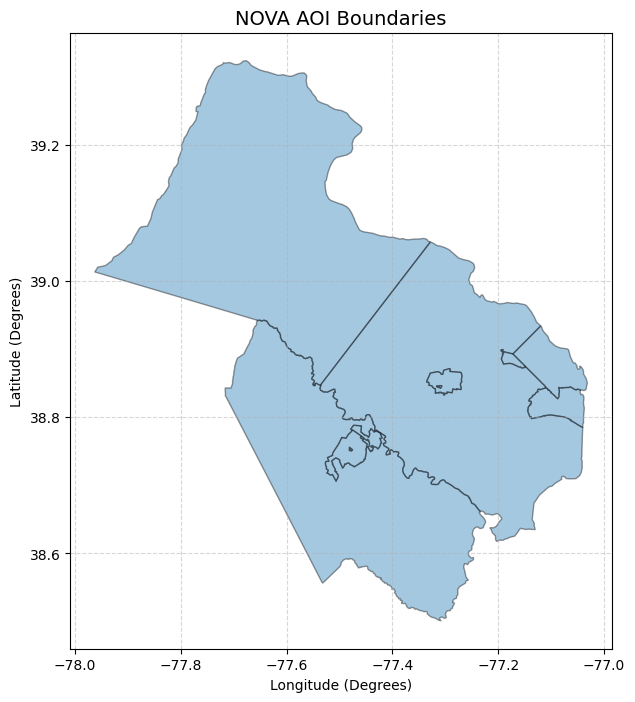

In [7]:
#this is a visualization of the aoi boundary for nova
fig, ax = plt.subplots(figsize=(10, 8))
aoi.plot(ax=ax, edgecolor='black', alpha=0.4)

plt.title("NOVA AOI Boundaries", fontsize=14)
plt.xlabel("Longitude (Degrees)", fontsize=10)
plt.ylabel("Latitude (Degrees)", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()


In [8]:
folder_path = "./NLCD_f6029387-cf80-4296-969b-7841753d3e04"

target_crs = aoi.crs

files = os.listdir(folder_path)
tiffs = [f for f in files if f.lower().endswith(('.tiff')) and not f.endswith('.xml')]
lc_file_name = [f for f in tiffs if "LndCov" in f][0]
full_input_path = os.path.join(folder_path, lc_file_name)


land_cover = (rioxarray.open_rasterio(full_input_path).rio.reproject(target_crs).rio.clip(aoi.geometry, target_crs))

land_cover.rio.to_raster("land_cover_fitted.tif")

print(land_cover.shape)


(1, 2651, 2996)


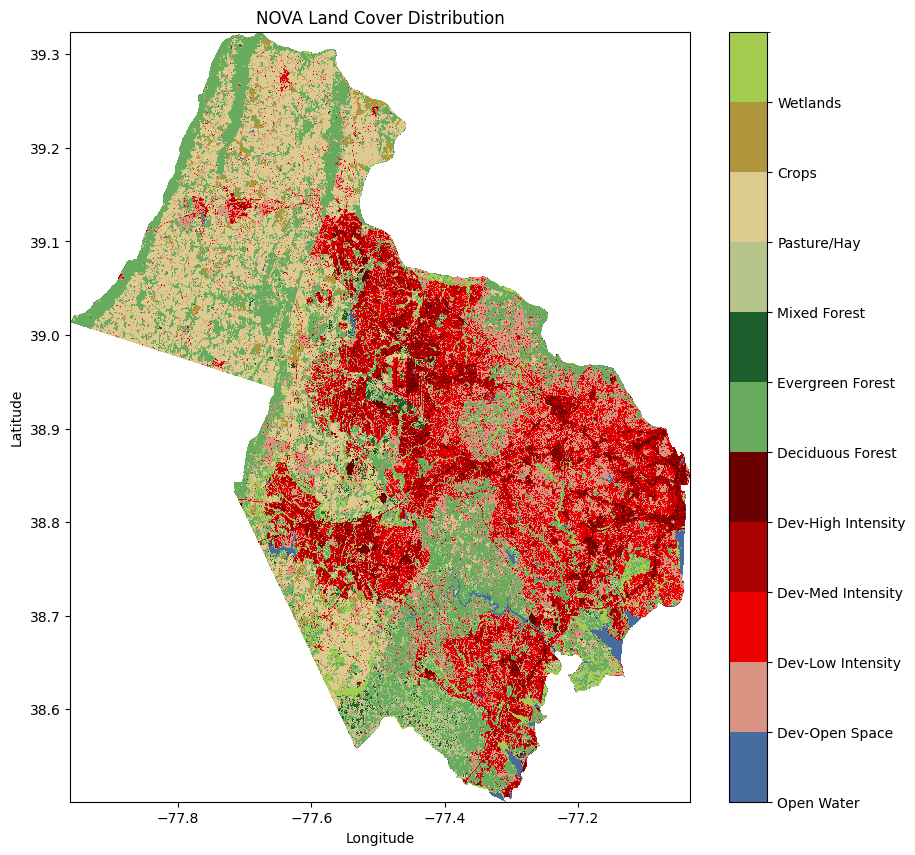

In [ ]:
lc_clean = land_cover.where(land_cover <= 100)

nlcd_dict = {
    11: ("#466b9f", "Open Water"),
    21: ("#d89382", "Dev-Open Space"),
    22: ("#ed0000", "Dev-Low Intensity"),
    23: ("#aa0000", "Dev-Med Intensity"),
    24: ("#6b0000", "Dev-High Intensity"),
    41: ("#68ab5f", "Deciduous Forest"),
    42: ("#1c5f2c", "Evergreen Forest"),
    43: ("#b5c58b", "Mixed Forest"),
    81: ("#dcca8f", "Pasture/Hay"),
    82: ("#af963c", "Crops"),
    90: ("#a3cc51", "Wetlands")
}

codes = sorted(nlcd_dict.keys())
colors = [nlcd_dict[c][0] for c in codes]
labels = [nlcd_dict[c][1] for c in codes]


cmap = ListedColormap(colors)
norm = BoundaryNorm(codes+[max(codes)+1], cmap.N)


fig, ax = plt.subplots(figsize=(10, 10))
im = lc_clean.plot(ax=ax, cmap=cmap, norm=norm, add_colorbar=False, )

cbar = plt.colorbar(im, ax=ax, ticks=codes, spacing="uniform")
cbar.ax.set_yticklabels(labels)

plt.title("NOVA Land Cover Distribution")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

In [ ]:
data = land_cover.values[0].astype('int16')
transform = land_cover.rio.transform()
nodata = land_cover.rio.nodata

#using a mask to ignore nodata
mask = (data != nodata)
shapes_gen = features.shapes(data, mask=mask, transform=transform)

#grouping by land cover class
grouped_geometries = defaultdict(list)
for geom, value in shapes_gen:
    grouped_geometries[int(value)].append(shape(geom))

#unionize and simlpifing for each class
final_data = []
for lc_value, geom_list in grouped_geometries.items():
    print(lc_value)
    merged_geom = unary_union([g.buffer(0) for g in geom_list])
    simplified_geom = merged_geom.simplify(tolerance=1.0, preserve_topology=True)
    final_data.append({"lc_value": lc_value, "geometry": simplified_geom})

gdf_final = gpd.GeoDataFrame(final_data, crs=land_cover.rio.crs)

gdf_final.to_file("land_cover.geojson", driver='GeoJSON', coordinate_precision=5)



Processing Land Cover Class 43...
Processing Land Cover Class 41...
Processing Land Cover Class 71...
Processing Land Cover Class 11...
Processing Land Cover Class 22...
Processing Land Cover Class 90...
Processing Land Cover Class 21...
Processing Land Cover Class 81...
Processing Land Cover Class 23...
Processing Land Cover Class 42...
Processing Land Cover Class 24...
Processing Land Cover Class 82...
Processing Land Cover Class 52...
Processing Land Cover Class 95...
Processing Land Cover Class 31...


In [11]:
folder_path = "./NLCD_f6029387-cf80-4296-969b-7841753d3e04"

target_crs = aoi.crs

files = os.listdir(folder_path)
tiffs = [f for f in files if f.lower().endswith(('.tiff')) and not f.endswith('.xml')]
fctimp_file_name = [f for f in tiffs if "FctImp" in f][0]
full_input_path = os.path.join(folder_path, fctimp_file_name)


fct_imp = (rioxarray.open_rasterio(full_input_path).rio.reproject(target_crs).rio.clip(aoi.geometry, target_crs))

fct_imp.rio.to_raster("fct_imp_fitted.tif")


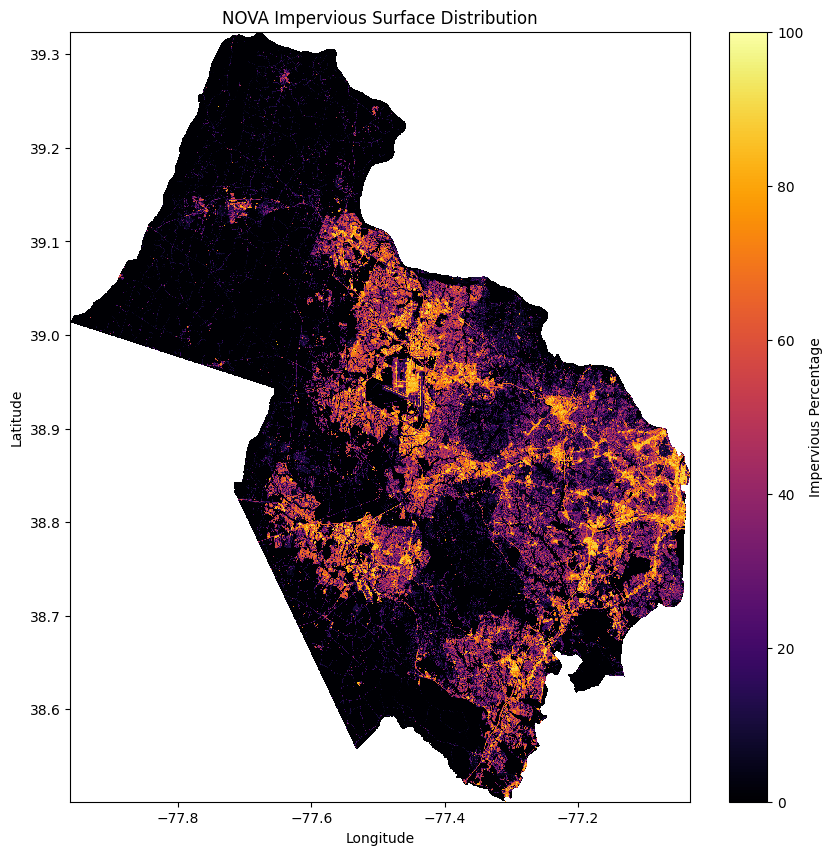

In [ ]:
#0-100 is normal range of %, anything above could be data error 
fct_imp_clean = fct_imp.where(fct_imp <= 100)


fig, ax = plt.subplots(figsize=(10, 10))

fct_imp_clean.plot(ax=ax, cmap="inferno", vmin=0, vmax=100, cbar_kwargs={'label': 'Impervious Percentage'})
ax.set_title("NOVA Impervious Surface Distribution")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()

In [12]:
data_raw = fct_imp.values[0].astype('float32')
data_min, data_max = data_raw.min(), data_raw.max()

#normalizing
normalized = (data_raw - data_min) / (data_max - data_min)

#preparing data for binning
data_for_binning = (normalized * 100).astype('float32')

In [13]:
data_binned = (np.ceil(data_for_binning / 10.0) * 10).astype('int16')

#vectorizing 
transform = fct_imp.rio.transform()

#taking away class 0 because that is no concrete so anything above 0 is some level of imperviousness
#we also want to ignore any values above 100% because it could indicate some data error
mask = (data_binned > 0) & (data_binned <= 100)
shapes_gen = features.shapes(data_binned, mask=mask, transform=transform)

#grouping by imperviousness bin
grouped_geometries = defaultdict(list)
for geom, value in shapes_gen:
    grouped_geometries[int(value)].append(shape(geom))

final_data = []
for val, geom_list in grouped_geometries.items():
    merged = unary_union([g.buffer(0) for g in geom_list])
    final_data.append({"imp_level": val, "geometry": merged.simplify(2.0)})

#saving as geoJson
gdf_imp = gpd.GeoDataFrame(final_data, crs=target_crs)
gdf_imp.to_file("fct_imp.geojson", driver='GeoJSON', coordinate_precision=5)